<a href="https://colab.research.google.com/github/isil-ada/cifar10-multi-CNN-benchmark/blob/main/notebook_02_model2_bn_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YZM304 Derin Öğrenme – Proje 2
## Model 2: BatchNorm + Dropout CNN — CIFAR-10
**Amaç:** Model 1 mimarisi korunarak BatchNorm ve Dropout eklenmesinin etkisini gözlemlemek.  
> **Önemli:** Model 1 ile **aynı train/test seti** kullanılır.

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as transforms
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {DEVICE}')

Cihaz: cuda


In [2]:
BATCH_SIZE, LEARNING_RATE, EPOCHS, NUM_CLASSES = 128, 0.001, 30, 10
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2023, 0.1994, 0.2010]

In [3]:
# ── Veri Yükleme (Model 1 ile AYNI) ──────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_set = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)
train_loader = torch.utils.data.DataLoader(train_set, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Eğitim: {len(train_set)} | Test: {len(test_set)}')

100%|██████████| 170M/170M [00:06<00:00, 26.6MB/s]


Eğitim: 50000 | Test: 10000


In [4]:
# ── Model 2: Model 1 + BatchNorm + Dropout ────────────────────────────────────
# Değişiklikler (Model 1'e kıyasla):
#   [+] Her Conv'dan sonra BatchNorm2d  → eğitim stabilitesi, hızlı yakınsama
#   [+] FC'den önce Dropout(0.5)        → aşırı öğrenme baskılama
#   [+] FC arasında Dropout(0.3)        → ek regularizasyon
#   [=] Tüm katman boyutları ve kernel boyutları Model 1 ile AYNI

class LeNet5CIFARv2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=5),   # Model 1 ile aynı
            nn.BatchNorm2d(32),                  # YENİ
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=5),   # Model 1 ile aynı
            nn.BatchNorm2d(64),                  # YENİ
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),                   # YENİ
            nn.Linear(64*5*5, 512),              # Model 1 ile aynı
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),                   # YENİ
            nn.Linear(512, num_classes),         # Model 1 ile aynı
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model2 = LeNet5CIFARv2(NUM_CLASSES).to(DEVICE)
print(model2)
print(f'\nToplam parametre: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}')

LeNet5CIFARv2(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1600, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)

Toplam parametre: 878,730


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [6]:
def train_epoch(model, loader, crit, opt, dev):
    model.train()
    ls, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        opt.zero_grad(); out = model(X); loss = crit(out, y)
        loss.backward(); opt.step()
        ls += loss.item()*X.size(0)
        correct += out.argmax(1).eq(y).sum().item(); total += y.size(0)
    return ls/total, 100.*correct/total

@torch.no_grad()
def eval_epoch(model, loader, crit, dev):
    model.eval()
    ls, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        out = model(X); loss = crit(out, y)
        ls += loss.item()*X.size(0)
        correct += out.argmax(1).eq(y).sum().item(); total += y.size(0)
    return ls/total, 100.*correct/total

In [7]:
hist = {'tl':[],'ta':[],'vl':[],'va':[]}
best_acc = 0.; t0 = time.time()

for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model2, train_loader, criterion, optimizer, DEVICE)
    vl, va = eval_epoch (model2, test_loader,  criterion, DEVICE)
    scheduler.step()
    for k,v in zip(['tl','ta','vl','va'],[tl,ta,vl,va]): hist[k].append(v)
    if va > best_acc:
        best_acc = va; torch.save(model2.state_dict(), 'model2_best.pth')
    if ep % 5 == 0 or ep == 1:
        print(f'[{ep:02d}/{EPOCHS}]  Train L:{tl:.4f} A:{ta:.2f}%  |  Val L:{vl:.4f} A:{va:.2f}%')

print(f'\nSüre: {time.time()-t0:.1f}s  |  En iyi: {best_acc:.2f}%')
np.save('model2_results.npy', {'best_acc': best_acc, 'history': hist})

[01/30]  Train L:1.5807 A:42.03%  |  Val L:1.2210 A:55.88%
[05/30]  Train L:1.1243 A:59.94%  |  Val L:0.9101 A:67.33%
[10/30]  Train L:0.9725 A:65.85%  |  Val L:0.7735 A:72.86%
[15/30]  Train L:0.8697 A:69.55%  |  Val L:0.6861 A:76.56%
[20/30]  Train L:0.8369 A:70.53%  |  Val L:0.6649 A:77.09%
[25/30]  Train L:0.7841 A:72.41%  |  Val L:0.6170 A:78.96%
[30/30]  Train L:0.7691 A:73.06%  |  Val L:0.6060 A:78.95%

Süre: 603.3s  |  En iyi: 79.34%


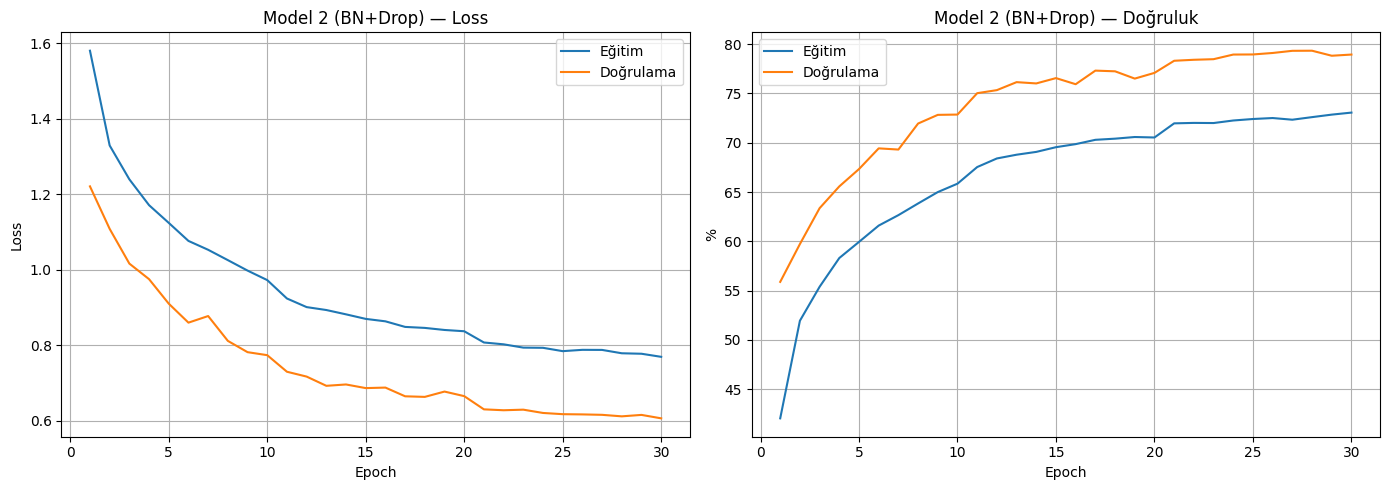

In [8]:
ep_r = range(1, EPOCHS+1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(ep_r, hist['tl'], label='Eğitim');  a1.plot(ep_r, hist['vl'], label='Doğrulama')
a1.set(title='Model 2 (BN+Drop) — Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid()
a2.plot(ep_r, hist['ta'], label='Eğitim');  a2.plot(ep_r, hist['va'], label='Doğrulama')
a2.set(title='Model 2 (BN+Drop) — Doğruluk', xlabel='Epoch', ylabel='%'); a2.legend(); a2.grid()
plt.tight_layout(); plt.savefig('model2_curves.png', dpi=150); plt.show()

=== Sınıflandırma Raporu — Model 2 ===
              precision    recall  f1-score   support

       plane       0.79      0.85      0.82      1000
         car       0.92      0.88      0.90      1000
        bird       0.74      0.66      0.70      1000
         cat       0.62      0.60      0.61      1000
        deer       0.78      0.78      0.78      1000
         dog       0.69      0.72      0.70      1000
        frog       0.83      0.87      0.85      1000
       horse       0.81      0.82      0.82      1000
        ship       0.90      0.87      0.88      1000
       truck       0.85      0.89      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



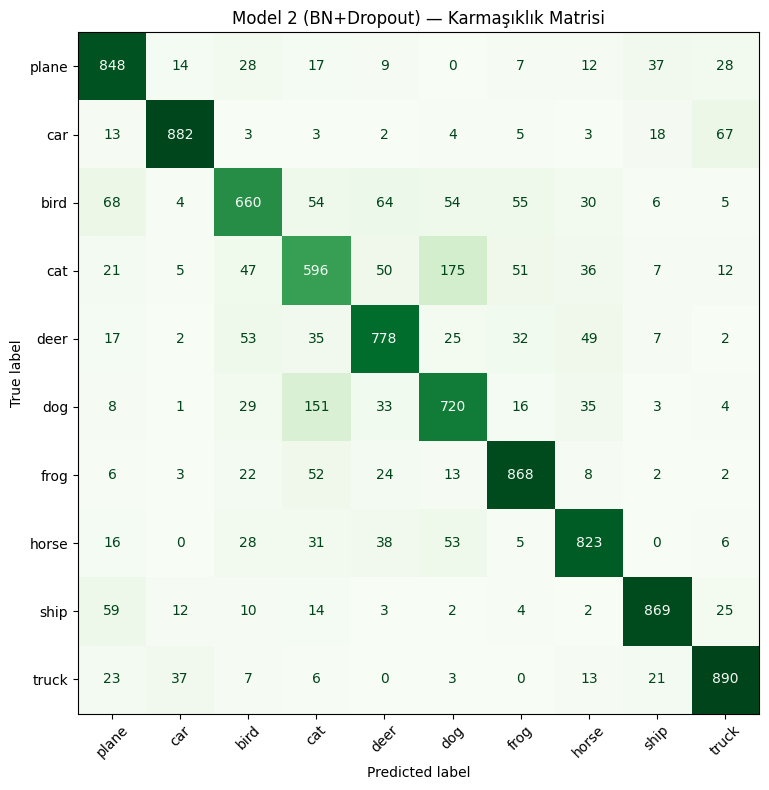


Model 2 Nihai Test Doğruluğu: 79.34%


In [9]:
model2.load_state_dict(torch.load('model2_best.pth', map_location=DEVICE))
model2.eval()
preds, labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        preds.extend(model2(X.to(DEVICE)).argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print('=== Sınıflandırma Raporu — Model 2 ===')
print(classification_report(labels, preds, target_names=CLASSES))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax,cmap='Greens',colorbar=False,xticks_rotation=45)
ax.set_title('Model 2 (BN+Dropout) — Karmaşıklık Matrisi')
plt.tight_layout(); plt.savefig('model2_confusion.png', dpi=150); plt.show()
print(f'\nModel 2 Nihai Test Doğruluğu: {best_acc:.2f}%')